##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

True Labels:       [0, 1, 1, 1]
Predicted Cluster: [1, 0, 0, 1]

Clustering Accuracy: 75.00%


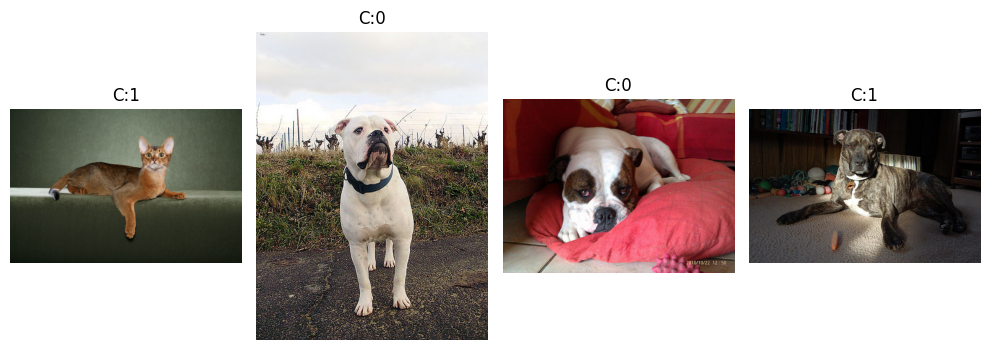

In [5]:
import os
import torch
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from transformers import AutoImageProcessor, AutoModel
import matplotlib.pyplot as plt

# Load DINOv2 model
model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()

# Read uploaded images directly from Colab

image_files = [
    "cat_1.jpg",
    "dog_1.jpg",
    "dog_2.jpg",
    "dog_3.jpg"
]

features = []
true_labels = []

# Extract CLS token from each image
for img_name in image_files:

    img_path = img_name

    image = Image.open(img_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token
    cls_token = outputs.last_hidden_state[:, 0, :].squeeze().numpy()

    features.append(cls_token)

    # Ground truth labels
    if "cat" in img_name.lower():
        true_labels.append(0)
    else:
        true_labels.append(1)

features = np.array(features)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
predicted_clusters = kmeans.fit_predict(features)

# Handle cluster label flipping
acc1 = accuracy_score(true_labels, predicted_clusters)
acc2 = accuracy_score(true_labels, 1 - predicted_clusters)

best_accuracy = max(acc1, acc2)

print("True Labels:      ", true_labels)
print("Predicted Cluster:", predicted_clusters.tolist())
print(f"\nClustering Accuracy: {best_accuracy * 100:.2f}%")

# Visualize results
plt.figure(figsize=(10, 4))

for i, img_name in enumerate(image_files):

    image = Image.open(img_name)

    plt.subplot(1, len(image_files), i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.title(f"C:{predicted_clusters[i]}")

plt.tight_layout()
plt.show()

In [6]:
 !wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!tar -xzf images.tar.gz

--2026-05-15 22:29:05--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-05-15 22:29:05--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  28.2MB/s    in 28s     

2026-05-15 22:29:34 (27.0 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]



Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

True Labels:       [0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0]
Predicted Cluster: [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1]

Clustering Accuracy: 100.00%


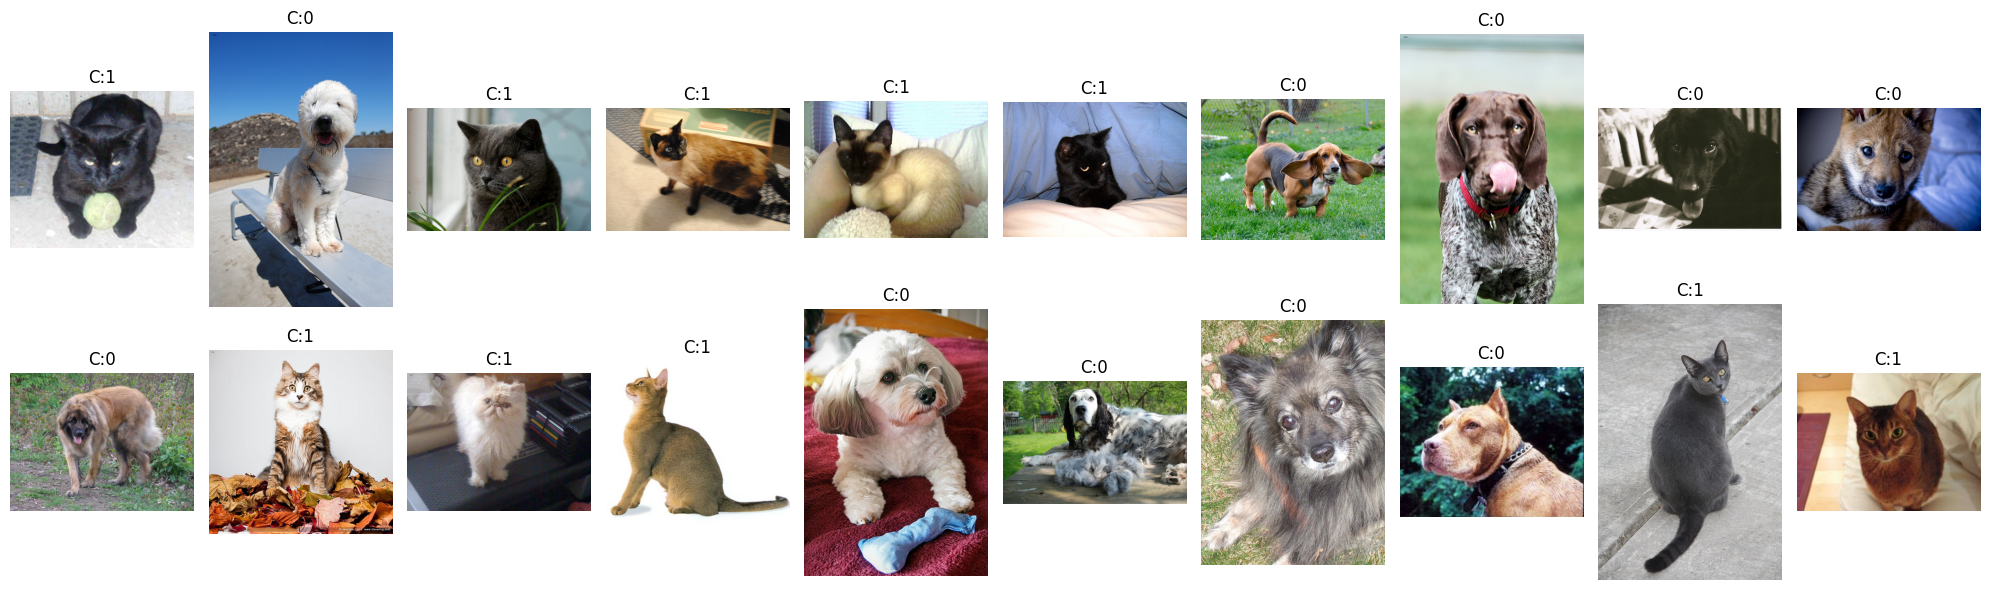

In [7]:
import os
import random
import torch
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from transformers import AutoImageProcessor, AutoModel
import matplotlib.pyplot as plt

# Load DINOv2 model
model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()

# Read all images from dataset
all_images = os.listdir("images")

# Cats filenames start with uppercase letters
cats = [img for img in all_images if img[0].isupper()]

# Dogs filenames start with lowercase letters
dogs = [img for img in all_images if img[0].islower()]

# Select 10 cats and 10 dogs
selected_images = random.sample(cats, 10) + random.sample(dogs, 10)

# Shuffle images
random.shuffle(selected_images)

image_files = selected_images

features = []
true_labels = []

# Extract CLS token features
for img_name in image_files:

    img_path = os.path.join("images", img_name)

    image = Image.open(img_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token
    cls_token = outputs.last_hidden_state[:, 0, :].squeeze().numpy()

    features.append(cls_token)

    # Ground truth labels
    if img_name[0].isupper():
        true_labels.append(0)   # Cat
    else:
        true_labels.append(1)   # Dog

features = np.array(features)

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)

predicted_clusters = kmeans.fit_predict(features)

# Handle cluster flipping
acc1 = accuracy_score(true_labels, predicted_clusters)
acc2 = accuracy_score(true_labels, 1 - predicted_clusters)

best_accuracy = max(acc1, acc2)

print("True Labels:      ", true_labels)
print("Predicted Cluster:", predicted_clusters.tolist())
print(f"\nClustering Accuracy: {best_accuracy * 100:.2f}%")

# Visualization
plt.figure(figsize=(20, 6))

for i, img_name in enumerate(image_files):

    image = Image.open(os.path.join("images", img_name))

    plt.subplot(2, 10, i + 1)

    plt.imshow(image)
    plt.axis("off")

    plt.title(f"C:{predicted_clusters[i]}")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

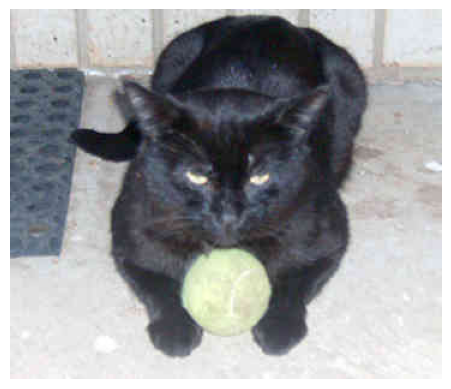

Predicted Class: Egyptian cat


In [8]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import matplotlib.pyplot as plt

# Model
model_name = "facebook/dinov2-small-imagenet1k-1-layer"

# Load processor and model
processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(model_name)

model.eval()

# Choose one image from dataset
image_path = os.path.join("images", image_files[0])

image = Image.open(image_path).convert("RGB")

# Display image
plt.imshow(image)
plt.axis("off")
plt.show()

# Preprocess image
inputs = processor(images=image, return_tensors="pt")

# Inference
with torch.no_grad():
    outputs = model(**inputs)

# Prediction
logits = outputs.logits

predicted_class_idx = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_idx]

print("Predicted Class:", predicted_label)

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

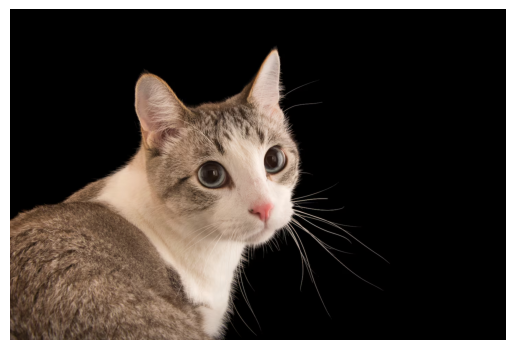

Predicted Class: tabby, tabby cat


In [9]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import matplotlib.pyplot as plt

# Load model
model_name = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(model_name)

model.eval()

# Load your uploaded image
image = Image.open("online_img.avif").convert("RGB")

# Display image
plt.imshow(image)
plt.axis("off")
plt.show()

# Preprocess image
inputs = processor(images=image, return_tensors="pt")

# Run inference
with torch.no_grad():
    outputs = model(**inputs)

# Get prediction
logits = outputs.logits

predicted_class_idx = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_idx]

# Print result
print("Predicted Class:", predicted_label)